Cell 1 — Load & Split

In [4]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# Step 1: price_per_sqft feature add karo
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']

# Step 2: log transform — price skewed hoti hai
df['price_log'] = np.log1p(df['price'])

X = df[['location_enc', 'total_sqft', 'bath', 'balcony', 'bhk', 'price_per_sqft']]
y = df['price_log']   # log price predict karenge

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Features:", X.columns.tolist())
print("Train size:", X_train.shape)

Features: ['location_enc', 'total_sqft', 'bath', 'balcony', 'bhk', 'price_per_sqft']
Train size: (7612, 6)


Cell 2 — Model Train karo

In [5]:
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)
print("Training done!")

[0]	validation_0-rmse:0.58925


[100]	validation_0-rmse:0.06139
[200]	validation_0-rmse:0.05304
[300]	validation_0-rmse:0.05267
[400]	validation_0-rmse:0.05254
[499]	validation_0-rmse:0.05244
Training done!


Cell 3 — Accuracy Check

MAE      : 4.41 lakhs
R2 Score : 0.8974
Accuracy : 89.74%


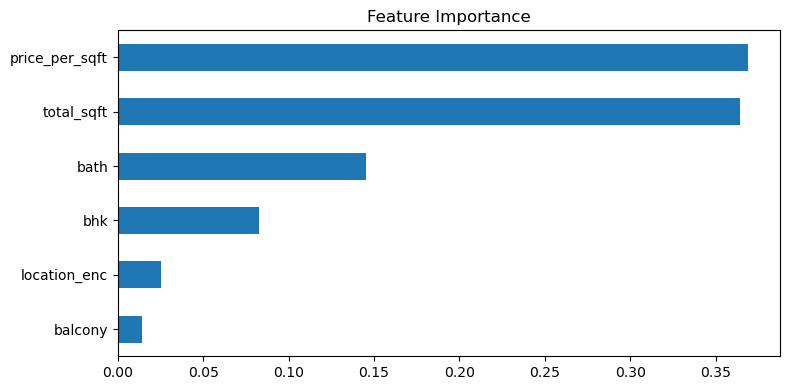

In [6]:
y_pred_log = model.predict(X_test)

# log se wapas original price mein convert
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2  = r2_score(y_test_actual, y_pred_actual)

print(f"MAE      : {mae:.2f} lakhs")
print(f"R2 Score : {r2:.4f}")
print(f"Accuracy : {round(r2*100, 2)}%")

# Feature importance
import matplotlib.pyplot as plt
feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8,4), title='Feature Importance')
plt.tight_layout()
plt.show()

Cell 4 — Save (updated)

In [7]:
# Model save
joblib.dump(model, '../data/processed/model.pkl')

# Log transform flag save karo — API ko pata rahega
import json
meta = {
    "features": ['location_enc', 'total_sqft', 'bath', 'balcony', 'bhk', 'price_per_sqft'],
    "use_log_transform": True,
    "price_unit": "lakhs"
}
with open('../data/processed/model_meta.json', 'w') as f:
    json.dump(meta, f)

print("Saved: model.pkl + model_meta.json")

# Test prediction
sample = pd.DataFrame([{
    'location_enc': 50,
    'total_sqft': 1200,
    'bath': 2,
    'balcony': 1,
    'bhk': 2,
    'price_per_sqft': 5000
}])

pred_log = model.predict(sample)[0]
pred_price = np.expm1(pred_log)
print(f"Sample: 2BHK 1200sqft → Rs {round(pred_price, 2)} lakhs")

Saved: model.pkl + model_meta.json
Sample: 2BHK 1200sqft → Rs 55.20000076293945 lakhs
